In [6]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

In [7]:
min_heap = [534, 123, 1231233, 3, 5, 6, 7, 8, 12, 31]

heapq.heapify(min_heap)

min_heap

[3, 5, 6, 8, 31, 1231233, 7, 123, 12, 534]

In [8]:
def draw_heap(heap):
    if not heap:
        print("Куча пуста")
        return

    G = nx.DiGraph()
    labels = {}

    # 1. Строим граф на основе индексов heapq
    for i in range(len(heap)):
        G.add_node(i)
        labels[i] = str(heap[i])  # Значение элемента кучи как текст

        left = 2 * i + 1
        right = 2 * i + 2

        if left < len(heap):
            G.add_edge(i, left)
        if right < len(heap):
            G.add_edge(i, right)

    # 2. Формируем древовидную структуру (иерархический layout)
    # Используем алгоритм Graphviz, если он есть, либо стандартный shell/multipartite.
    # Для идеального дерева "из коробки" напишем простую функцию координат:
    pos = {}

    def get_postions(node, x=0, y=0, layer_width=1.0):
        if node >= len(heap):
            return
        pos[node] = (x, y)
        left = 2 * node + 1
        right = 2 * node + 2
        # Разносим ветки влево и вправо, уменьшая шаг с глубиной
        get_postions(left, x - layer_width / 2, y - 1, layer_width / 2)
        get_postions(right, x + layer_width / 2, y - 1, layer_width / 2)

    get_postions(0)

    # 3. Отрисовка
    plt.figure(figsize=(8, 6))
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=1200,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        arrows=True,
    )
    plt.title("Визуализация heapq структуры")
    plt.show()

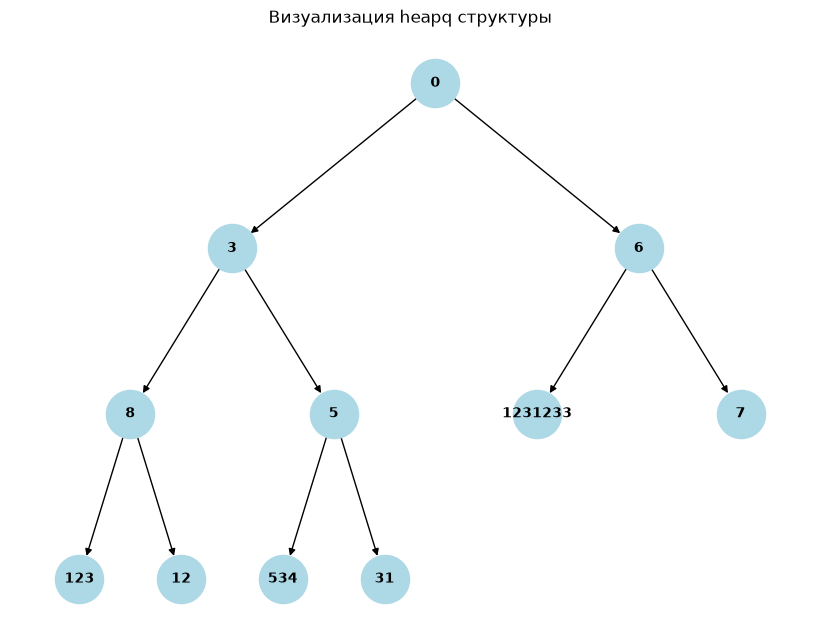

[0, 3, 6, 8, 5, 1231233, 7, 123, 12, 534, 31]

In [9]:
heapq.heappush(min_heap, 0)

draw_heap(min_heap)

min_heap

In [11]:
for _ in range(5):
    print(heapq.heappop(min_heap))

0
3
5
6
7


In [15]:
# min_heap -> max_heap
arr = [4, 1, 5, 6, 7, 8, 10, 12, 11]

max_heap = []

for num in arr:
    heapq.heappush(max_heap, -num)

print(-max_heap[0])
max_heap

12


[-12, -11, -8, -10, -5, -4, -7, -1, -6]

In [16]:
# 215. Kth Largest Element in an Array

In [ ]:
# O(N + logK)
class Solution:
    def findKthLargest(self, nums: list[int], k: int) -> int:
        max_heap = [-num for num in nums]

        # for num in nums:
        #     heapq.heappush(max_heap, -num)

        heapq.heapify(max_heap)

        for _ in range(k - 1):
            heapq.heappop(max_heap)

        return -max_heap[0]


# O(NlogN)
class Solution:
    def findKthLargest(self, nums: list[int], k: int) -> int:
        max_heap = []

        for num in nums:
            heapq.heappush(max_heap, -num)

        for _ in range(k - 1):
            heapq.heappop(max_heap)

        return -max_heap[0]

In [ ]:
# O(NlogK)
class Solution:
    def findKthLargest(self, nums: list[int], k: int) -> int:
        min_heap = []

        for num in nums:
            heapq.heappush(min_heap, num)
            if len(min_heap) > k:
                heapq.heappop(min_heap)

        return min_heap[0]

In [18]:
# 703. Kth Largest Element in a Stream

In [ ]:
class KthLargest:

    def __init__(self, k: int, nums: list[int]):
        self.min_heap = nums
        self.k = k

        heapq.heapify(self.min_heap)
        while len(self.min_heap) > k:
            heapq.heappop(self.min_heap)

    def add(self, val: int) -> int:
        heapq.heappush(self.min_heap, val)
        if len(self.min_heap) > self.k:
            heapq.heappop(self.min_heap)
        return self.min_heap[0]

In [ ]:
class KthLargest:
    def __init__(self, k: int, nums: list[int]):
        self.k = k
        self.max_heap = [-x for x in nums]
        heapq.heapify(self.max_heap)

    def add(self, val: int) -> int:
        heapq.heappush(self.max_heap, -val)
        
        # В max-heap самые большие элементы лежат наверху.
        # Чтобы найти k-й по величине элемент, нужно временно достать (k-1) самых больших.
        temp = []
        for _ in range(self.k - 1):
            temp.append(heapq.heappop(self.max_heap))
            
        # Теперь на вершине лежит k-й наибольший элемент
        kth_largest = -self.max_heap[0]
        
        # Возвращаем (k-1) элементов обратно в кучу, чтобы не сломать структуру
        for num in temp:
            heapq.heappush(self.max_heap, num)
            
        return kth_largest

In [19]:
# 347. Top K Frequent Elements

In [20]:
class Solution:
    def topKFrequent(self, nums: list[int], k: int) -> list[int]: 
        c = Counter(nums)

        min_heap = []
        for num, freq in c.items():
            heapq.heappush(min_heap, (freq, num))
            if len(min_heap) > k:
                heapq.heappop(min_heap)
            
        return [item[1] for item in min_heap]

In [ ]:
class Solution:
    def topKFrequent(self, nums: list[int], k: int) -> list[int]: 
        c = Counter(nums)
        max_heap = []

        for num, freq in c.items():
            heapq.heappush(max_heap, (-freq, num))

        res = []

        for _ in range(k):
            freq_inverted, num = heapq.heappop(max_heap)
            res.append(num)
        return res

In [ ]:
class Solution:
    def topKFrequent(self, nums: list[int], k: int) -> list[int]: 
        c = Counter(nums)
        
        # Сразу создаем список кортежей (-freq, num)
        max_heap = [(-freq, num) for num, freq in c.items()]
        
        # Превращаем список в кучу за O(N)
        heapq.heapify(max_heap)
            
        # Извлекаем k элементов за O(k log N)
        return [heapq.heappop(max_heap)[1] for _ in range(k)]

In [22]:
# 451. Sort Characters By Frequency

In [24]:
class Solution:
    def frequencySort(self, s: str) -> str:
        c = Counter(s)
        max_heap = []

        for ch, val in c.items():
            heapq.heappush(max_heap, (-val, ch*val))

        res = ""
        while max_heap:
            res += heapq.heappop(max_heap)[1]
        return res
        

In [25]:
class Solution:
    def frequencySort(self, s: str) -> str:
        c = Counter(s)
        
        # Собираем кортежи (частота, символ). 
        # Значения положительные, поэтому это min-heap.
        min_heap = [(freq, ch) for ch, freq in c.items()]
        
        # Строим кучу за O(N)
        heapq.heapify(min_heap)
        
        result = []
        
        # Достаем элементы от самых редких к самым частым
        while min_heap:
            freq, ch = heapq.heappop(min_heap)
            result.append(ch * freq)
            
        # Разворачиваем список, чтобы самые частые символы оказались в начале
        result.reverse()
        
        return "".join(result)